In [1]:
import torch
import torch.nn as nn
import numpy as np
import time
from itertools import chain
from torch.utils.data import DataLoader, TensorDataset

print("=" * 60)
print("Covert Timing Channel — TimeGAN + SAC Noise Injection")
print("=" * 60)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # ── Physical Constants ──
    PHYS_MIN = 0.0       # Giới hạn dưới không gian vật lý (giây)
    PHYS_MAX = 2.5       # Giới hạn trên không gian vật lý (giây)

    BIT0_TIME = 0.5      # Mốc thời gian cho Bit 0 (giây)
    BIT1_TIME = 1.0      # Mốc thời gian cho Bit 1 (giây)

    THRESHOLD_PHYS = 0.75   # Ngưỡng giải mã: Bit 0 phải ≤ giá trị này
    LOWER_BOUND_PHYS = 0.30 # Giới hạn dưới vật lý

    # ── Scaled versions (qua Fixed MinMax Scaler) ──
    BIT0_SCALED = (BIT0_TIME - PHYS_MIN) / (PHYS_MAX - PHYS_MIN)          # 0.20
    BIT1_SCALED = (BIT1_TIME - PHYS_MIN) / (PHYS_MAX - PHYS_MIN)          # 0.40
    THRESHOLD_SCALED = (THRESHOLD_PHYS - PHYS_MIN) / (PHYS_MAX - PHYS_MIN) # 0.30
    LOWER_BOUND_SCALED = (LOWER_BOUND_PHYS - PHYS_MIN) / (PHYS_MAX - PHYS_MIN) # 0.12

    print(f"\nBit 0: {BIT0_TIME}s → scaled {BIT0_SCALED:.2f}")
    print(f"Bit 1: {BIT1_TIME}s → scaled {BIT1_SCALED:.2f}")
    print(f"Threshold: {THRESHOLD_PHYS}s → scaled {THRESHOLD_SCALED:.2f}")
    print(f"Lower bound: {LOWER_BOUND_PHYS}s → scaled {LOWER_BOUND_SCALED:.2f}")

    # ── Hyperparameters ──
    SEQ_LEN = 24         # Chiều dài chuỗi thời gian
    HIDDEN_DIM = 24      # Chiều không gian ẩn
    NUM_LAYERS = 3        # Số lớp RNN
    EPOCHS = 200          # Số epoch mỗi phase
    BATCH_SIZE = 128
    LEARNING_RATE = 1e-3
    NOISE_SCALE = 0.4   # Cũ: 0.15 (Cho phép AI cộng/trừ tối đa 0.4 * 2.5s = 1.0s)
    ALPHA = 2.0         # Cũ: 0.5 (Ép AI vung nhiễu mạnh tay hơn để lấp đầy khoảng trống)
    NUM_SAMPLES = 10000   # Số mẫu dữ liệu cover traffic

    print(f"\nHyperparameters:")
    print(f"  seq_len={SEQ_LEN}, hidden_dim={HIDDEN_DIM}, layers={NUM_LAYERS}")
    print(f"  epochs={EPOCHS}, batch_size={BATCH_SIZE}, lr={LEARNING_RATE}")
    print(f"  noise_scale={NOISE_SCALE}, alpha={ALPHA}")

Covert Timing Channel — TimeGAN + SAC Noise Injection
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
Device: cuda

Bit 0: 0.5s → scaled 0.20
Bit 1: 1.0s → scaled 0.40
Threshold: 0.75s → scaled 0.30
Lower bound: 0.3s → scaled 0.12

Hyperparameters:
  seq_len=24, hidden_dim=24, layers=3
  epochs=200, batch_size=128, lr=0.001
  noise_scale=0.4, alpha=2.0


In [2]:
def get_rnn_class(module_name):
    """Trả về class RNN tương ứng (hỗ trợ GRU hoặc LSTM)."""
    assert module_name in ["gru", "lstm"], f"module_name phải là 'gru' hoặc 'lstm', nhận: {module_name}"
    return nn.GRU if module_name == "gru" else nn.LSTM

MODULE_NAME = "gru"  # Có thể đổi sang "lstm" nếu muốn


# ── Embedder ──

class Embedder(nn.Module):
    """Nén dữ liệu đầu vào (IPD scaled) vào không gian ẩn (Latent Space).

    Kiến trúc: RNN → Linear → Sigmoid
    Input:  (batch, seq_len, input_features)  ví dụ (128, 24, 1)
    Output: (batch, seq_len, hidden_dim)      ví dụ (128, 24, 24)

    Sigmoid ở output vì hidden state cần bounded [0, 1] cho GAN training ổn định.
    Giữ nguyên từ mctimegan.py — KHÔNG SỬA ĐỔI.
    """

    def __init__(self, module_name, input_features, hidden_dim, num_layers):
        super().__init__()
        rnn_class = get_rnn_class(module_name)
        self.rnn = rnn_class(
            input_size=input_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid())

    def forward(self, x):
        """Forward pass. x: (batch, seq_len, features) → h: (batch, seq_len, hidden_dim)"""
        seq, _ = self.rnn(x)
        return self.fc(seq)


# ── Recovery ──

class Recovery(nn.Module):
    """Giải nén từ không gian ẩn về không gian dữ liệu.

    Kiến trúc: RNN → Linear → Sigmoid
    Input:  (batch, seq_len, hidden_dim)      ví dụ (128, 24, 24)
    Output: (batch, seq_len, input_features)  ví dụ (128, 24, 1)

    Sigmoid vì dữ liệu đã scale về [0, 1] qua Fixed MinMax Scaler.
    Giữ nguyên từ mctimegan.py — KHÔNG SỬA ĐỔI.
    """

    def __init__(self, module_name, input_features, hidden_dim, num_layers):
        super().__init__()
        rnn_class = get_rnn_class(module_name)
        self.rnn = rnn_class(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Sequential(nn.Linear(hidden_dim, input_features), nn.Sigmoid())

    def forward(self, h):
        """Forward pass. h: (batch, seq_len, hidden_dim) → x_tilde: (batch, seq_len, features)"""
        seq, _ = self.rnn(h)
        return self.fc(seq)


# ── Supervisor ──

class Supervisor(nn.Module):
    """Học liên kết thời gian (Temporal Dynamics) trong không gian ẩn.

    Kiến trúc: RNN (ít hơn 1 layer) → Linear → Sigmoid
    Input:  (batch, seq_len, hidden_dim)
    Output: (batch, seq_len, hidden_dim)

    Dùng ít hơn 1 layer so với Generator/Embedder (max(1, num_layers-1))
    để tạo bottleneck, buộc Generator tự học temporal dynamics.
    Giữ nguyên từ mctimegan.py — KHÔNG SỬA ĐỔI.
    """

    def __init__(self, module_name, hidden_dim, num_layers):
        super().__init__()
        rnn_class = get_rnn_class(module_name)
        self.rnn = rnn_class(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=max(1, num_layers - 1),  # Đảm bảo ít nhất 1 layer
            batch_first=True,
        )
        self.fc = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid())

    def forward(self, h):
        """Forward pass. h: (batch, seq_len, hidden_dim) → h_hat: (batch, seq_len, hidden_dim)"""
        seq, _ = self.rnn(h)
        return self.fc(seq)


# ── NoiseGenerator (Tanh Additive — Shared Seed Decoding) ──

class NoiseGenerator(nn.Module):
    """Bộ Sinh Nhiễu Cộng Gộp cho Covert Timing Channel.

    Phiên bản 4 (Final): Tanh additive, KHÔNG constraint.

    Tại sao bỏ hard constraint:
    - Hard constraint tại 0.75s tạo "vết cắt" trong phân phối
    - Real traffic trơn qua 0.75s, fake traffic CẮT ĐÔI → classifier bắt 95.5%
    - Dùng Shared Seed → receiver decode bằng so sánh, KHÔNG cần threshold

    Kiến trúc: [Z, C_scaled] → GRU → Linear → Tanh × noise_scale
    Output:   final_ipd = C_scaled + delta_t
              delta_t ∈ (-noise_scale, +noise_scale)

    Decoding (Shared Seed — 2-pass):
      1. Receiver biết seed → tái tạo Z
      2. Try bit=0: expected_0 = Generator(Z, C_scaled=0.20)
      3. Try bit=1: expected_1 = Generator(Z, C_scaled=0.40)
      4. bit = argmin |received_ipd - expected_i|
    """

    def __init__(self, module_name, input_dim, hidden_dim, num_layers, noise_scale=0.15):
        super().__init__()
        rnn_class = get_rnn_class(module_name)
        self.rnn = rnn_class(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.noise_head = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )
        self.noise_scale = noise_scale

    def forward(self, z, c_scaled):
        """
        Args:
            z: (batch, seq_len, 1) — nhiễu ngẫu nhiên (từ shared seed)
            c_scaled: (batch, seq_len, 1) — 0.20 (Bit 0) hoặc 0.40 (Bit 1)
        Returns:
            final_ipd_scaled: C_scaled + delta_t  (batch, seq_len, 1)
            delta_t: nhiễu additive               (batch, seq_len, 1)
        """
        x = torch.cat([z, c_scaled], dim=-1)
        seq, _ = self.rnn(x)
        delta_t = self.noise_head(seq) * self.noise_scale
        final_ipd_scaled = c_scaled + delta_t
        return final_ipd_scaled, delta_t

# ── Discriminator ──

class Discriminator(nn.Module):
    """Phân biệt dữ liệu thật/giả trong không gian ẩn (hidden space).

    Kiến trúc: Bidirectional RNN → Linear
    Input:  (batch, seq_len, hidden_dim)
    Output: (batch, seq_len, 1) — logit (chưa qua sigmoid)

    Dùng Bidirectional để phân tích cả quá khứ và tương lai
    → phát hiện pattern bất thường ở bất kỳ vị trí nào trong chuỗi.
    Giữ nguyên từ mctimegan.py — KHÔNG SỬA ĐỔI.
    """

    def __init__(self, module_name, hidden_dim, num_layers):
        super().__init__()
        rnn_class = get_rnn_class(module_name)
        self.rnn = rnn_class(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
        )
        self.fc = nn.Linear(2 * hidden_dim, 1)

    def forward(self, h):
        """Forward pass. h: (batch, seq_len, hidden_dim) → y: (batch, seq_len, 1)"""
        seq, _ = self.rnn(h)
        return self.fc(seq)


# =============================================================================
# Loss Functions
# Giữ nguyên từ mctimegan.py, bổ sung thêm cho bài toán Covert Channel.
# =============================================================================

def embedder_loss(x, x_tilde):
    """Loss cho Embedder: reconstruction error.
    Dùng sqrt(MSE) × 10 — hệ số 10 đảm bảo gradient đủ mạnh.
    Gốc: mctimegan.py line 252–254."""
    return 10.0 * torch.sqrt(nn.MSELoss()(x, x_tilde))


def supervisor_loss(h, h_hat_sup):
    """Loss cho Supervisor: dự đoán hidden state tiếp theo.
    So sánh h[1:] (ground truth) với h_hat[:-1] (prediction).
    Gốc: mctimegan.py line 257–259."""
    return nn.MSELoss()(h[:, 1:, :], h_hat_sup[:, :-1, :])


def discriminator_loss(y_real, y_fake):
    """Loss Discriminator: BCE trên real + fake.
    Real → label 1, Fake → label 0.
    Gốc: mctimegan.py line 216–230 (đơn giản hóa — bỏ y_fake_e
    vì Covert Channel chỉ có 1 nhánh fake từ NoiseGenerator,
    không có HiddenGenerator → Supervisor → nhánh thứ 2)."""
    real_labels = torch.ones_like(y_real, device=device, requires_grad=False)
    fake_labels = torch.zeros_like(y_fake, device=device, requires_grad=False)
    return (nn.BCEWithLogitsLoss()(y_real, real_labels) +
            nn.BCEWithLogitsLoss()(y_fake, fake_labels))


def generator_gan_loss(y_fake):
    """GAN Loss Generator: lừa Discriminator.
    Generator muốn fake → classified as real (label 1).
    Gốc: mctimegan.py line 233–241 (đơn giản hóa — bỏ y_fake_e)."""
    target_real = torch.ones_like(y_fake, device=device, requires_grad=False)
    return nn.BCEWithLogitsLoss()(y_fake, target_real)


def generator_moment_loss(x_real, x_fake):
    """Moment Matching Loss: khớp mean và std giữa real và fake.

    2 moment (giữ nguyên từ mctimegan.py line 244–247):
    - Moment 1 (std): |std(fake) - std(real)| theo từng feature
    - Moment 2 (mean): |mean(fake) - mean(real)| theo từng feature

    Đảm bảo phân phối sinh ra có cùng thống kê bậc 1 và bậc 2 với real data.
    """
    g_loss_v1 = torch.mean(torch.abs(
        torch.std(x_fake, dim=0) - torch.std(x_real, dim=0)
    ))
    g_loss_v2 = torch.mean(torch.abs(
        torch.mean(x_fake, dim=0) - torch.mean(x_real, dim=0)
    ))
    return g_loss_v1 + g_loss_v2


print(f"✅ All networks defined! (module: {MODULE_NAME})")
print(f"   Embedder → Recovery: Autoencoder (Phase 1, giữ nguyên từ TimeGAN)")
print(f"   Supervisor: Temporal dynamics (Phase 2, giữ nguyên từ TimeGAN)")
print(f"   NoiseGenerator: Additive noise delta_t (Phase 3, THAY THẾ Generator gốc)")
print(f"   Discriminator: Bidirectional (Phase 3, giữ nguyên từ TimeGAN)")

✅ All networks defined! (module: gru)
   Embedder → Recovery: Autoencoder (Phase 1, giữ nguyên từ TimeGAN)
   Supervisor: Temporal dynamics (Phase 2, giữ nguyên từ TimeGAN)
   NoiseGenerator: Additive noise delta_t (Phase 3, THAY THẾ Generator gốc)
   Discriminator: Bidirectional (Phase 3, giữ nguyên từ TimeGAN)


In [3]:
def generate_cover_traffic(num_samples, seq_len):
    """Sinh dữ liệu cover traffic để huấn luyện Discriminator.

    Trộn 2 phân phối:
    - 80% N(0.8, 0.3): phân phối chính của lưu lượng IoT (ĐÃ MỞ RỘNG TỪ 0.15)
    - 20% U(0.2, 1.5): tail coverage — để Discriminator "biết"
      cả vùng thấp (0.2–0.5s) mà Bit 0 + nhiễu có thể rơi vào.
    """
    n_normal = int(num_samples * 0.8)
    n_uniform = num_samples - n_normal

    normal_data = np.random.normal(0.75, 0.3, (n_normal, seq_len, 1))
    uniform_data = np.random.uniform(0.2, 1.5, (n_uniform, seq_len, 1))

    data = np.concatenate([normal_data, uniform_data], axis=0)
    data = np.clip(data, 0.1, 2.0) 

    np.random.shuffle(data)
    return data.astype(np.float32)


def scale_data(data_phys):
    """Fixed MinMax Scaler: scale về [0, 1] dùng hằng số vật lý cố định.
    Tránh nghẽn Sigmoid ở Recovery network."""
    return (data_phys - PHYS_MIN) / (PHYS_MAX - PHYS_MIN)


def inverse_scale(data_scaled):
    """Inverse Fixed MinMax Scaler: chuyển về giá trị vật lý (giây)."""
    return data_scaled * (PHYS_MAX - PHYS_MIN) + PHYS_MIN


# Sinh và scale cover traffic
cover_data_phys = generate_cover_traffic(NUM_SAMPLES, SEQ_LEN)
cover_data_scaled = scale_data(cover_data_phys)

print(f"✅ Cover traffic generated!")
print(f"   Shape: {cover_data_scaled.shape}")
print(f"   Physical range: [{cover_data_phys.min():.4f}s, {cover_data_phys.max():.4f}s]")
print(f"   Scaled range: [{cover_data_scaled.min():.4f}, {cover_data_scaled.max():.4f}]")
print(f"   Physical mean: {cover_data_phys.mean():.4f}s, std: {cover_data_phys.std():.4f}s")

✅ Cover traffic generated!
   Shape: (10000, 24, 1)
   Physical range: [0.1000s, 2.0000s]
   Scaled range: [0.0400, 0.8000]
   Physical mean: 0.7714s, std: 0.3157s


In [4]:
cover_tensor = torch.tensor(cover_data_scaled, dtype=torch.float32, device=device)
cover_dataset = TensorDataset(cover_tensor)

print(f"✅ Data prepared!")
print(f"   Tensor shape: {cover_tensor.shape}")
print(f"   Device: {cover_tensor.device}")

✅ Data prepared!
   Tensor shape: torch.Size([10000, 24, 1])
   Device: cuda:0


In [5]:
embedder = Embedder(MODULE_NAME, 1, HIDDEN_DIM, NUM_LAYERS).to(device)
recovery = Recovery(MODULE_NAME, 1, HIDDEN_DIM, NUM_LAYERS).to(device)
supervisor = Supervisor(MODULE_NAME, HIDDEN_DIM, NUM_LAYERS).to(device)

# ── Phase 1: Embedding Network Training ──
print("\n🔹 Phase 1: Embedding Network Training")
optimizer_er = torch.optim.Adam(
    chain(embedder.parameters(), recovery.parameters()),
    lr=LEARNING_RATE
)

for epoch in range(EPOCHS):
    embedder.train()
    recovery.train()
    losses = []

    for (x,) in DataLoader(cover_dataset, batch_size=BATCH_SIZE, shuffle=True):
        optimizer_er.zero_grad()
        h = embedder(x)
        x_tilde = recovery(h)
        loss = embedder_loss(x, x_tilde)
        loss.backward()
        optimizer_er.step()
        losses.append(loss.item())

    if (epoch + 1) % (EPOCHS // 10) == 0:
        print(f"   Epoch {epoch+1}/{EPOCHS} | loss_e: {np.mean(losses):.6f}")

print("   ✓ Embedding training complete!")


# ── Phase 2: Supervisor Training ──
print("\n🔹 Phase 2: Supervised Training")
optimizer_s = torch.optim.Adam(supervisor.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    supervisor.train()
    losses = []

    for (x,) in DataLoader(cover_dataset, batch_size=BATCH_SIZE, shuffle=True):
        optimizer_s.zero_grad()
        # Embedder frozen (no gradient update qua optimizer_s)
        with torch.no_grad():
            h = embedder(x)
        h_hat = supervisor(h)
        loss = supervisor_loss(h, h_hat)
        loss.backward()
        optimizer_s.step()
        losses.append(loss.item())

    if (epoch + 1) % (EPOCHS // 10) == 0:
        print(f"   Epoch {epoch+1}/{EPOCHS} | loss_s: {np.mean(losses):.6f}")

print("   ✓ Supervised training complete!")


🔹 Phase 1: Embedding Network Training
   Epoch 20/200 | loss_e: 0.051210
   Epoch 40/200 | loss_e: 0.039454
   Epoch 60/200 | loss_e: 0.028026
   Epoch 80/200 | loss_e: 0.038076
   Epoch 100/200 | loss_e: 0.019678
   Epoch 120/200 | loss_e: 0.018740
   Epoch 140/200 | loss_e: 0.015734
   Epoch 160/200 | loss_e: 0.016296
   Epoch 180/200 | loss_e: 0.015701
   Epoch 200/200 | loss_e: 0.014726
   ✓ Embedding training complete!

🔹 Phase 2: Supervised Training
   Epoch 20/200 | loss_s: 0.019227
   Epoch 40/200 | loss_s: 0.019224
   Epoch 60/200 | loss_s: 0.019201
   Epoch 80/200 | loss_s: 0.019187
   Epoch 100/200 | loss_s: 0.019210
   Epoch 120/200 | loss_s: 0.019188
   Epoch 140/200 | loss_s: 0.019187
   Epoch 160/200 | loss_s: 0.019181
   Epoch 180/200 | loss_s: 0.019184
   Epoch 200/200 | loss_s: 0.019194
   ✓ Supervised training complete!


In [6]:
generator = NoiseGenerator(
    module_name=MODULE_NAME,
    input_dim=2,  # [Z, C_scaled]
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    noise_scale=NOISE_SCALE
).to(device)

discriminator_net = Discriminator(MODULE_NAME, HIDDEN_DIM, NUM_LAYERS).to(device)

optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE)
optimizer_d = torch.optim.Adam(discriminator_net.parameters(), lr=LEARNING_RATE * 0.5)  # D chậm hơn G
# Embedder + Recovery cũng update nhẹ trong Phase 3
optimizer_er3 = torch.optim.Adam(
    chain(embedder.parameters(), recovery.parameters()),
    lr=LEARNING_RATE * 0.5  # Đã trained, chỉ fine-tune nhẹ
)

# ── Learning Rate Schedulers ──
# CosineAnnealing: LR giảm mượt từ lr_init → eta_min theo hình cosine
scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_g, T_max=EPOCHS, eta_min=1e-5)
scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_d, T_max=EPOCHS, eta_min=1e-5)
scheduler_er3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_er3, T_max=EPOCHS, eta_min=1e-5)

print("\n🔹 Phase 3: Joint Training (GAN + Penalty + SAC Entropy + Moment)")
training_losses = []
start_time = time.time()

for epoch in range(EPOCHS):
    g_losses, d_losses, e_losses = [], [], []
    moment_vals, entropy_vals = [], []

    # ── Train Generator 2 lần, Discriminator 1 lần ──
    for _ in range(2):
        loader = DataLoader(cover_dataset, batch_size=BATCH_SIZE, shuffle=True)

        for (x_real,) in loader:
            bs = x_real.size(0)

            # ====== GENERATOR TRAINING ======
            generator.train()
            embedder.train()
            optimizer_g.zero_grad()

            # Sinh nhiễu ngẫu nhiên Z và condition C
            z = torch.rand(bs, SEQ_LEN, 1, device=device)
            bits = torch.randint(0, 2, (bs, SEQ_LEN, 1), device=device).float()
            c_phys = torch.where(bits == 0, BIT0_TIME, BIT1_TIME)
            c_scaled = (c_phys - PHYS_MIN) / (PHYS_MAX - PHYS_MIN)

            # Generator sinh nhiễu + Tiêm nhiễu cộng gộp
            final_ipd_scaled, delta_t = generator(z, c_scaled)

            # Embed dữ liệu giả → GAN trong không gian ẩn
            h_fake = embedder(final_ipd_scaled)
            y_fake = discriminator_net(h_fake)

            # ── 1. GAN Loss: Lừa Discriminator ──
            # (Giữ dù yếu — có thể giúp ở late training khi D bắt đầu học)
            gan_loss = generator_gan_loss(y_fake)

            # NOTE: KHÔNG CẦN Penalty — reliability = 100% by construction.
            # NoiseGenerator v3 hard-constrain output:
            #   Bit 0 ∈ (0.30, 0.75)s → luôn < threshold ✓
            #   Bit 1 ∈ (0.75, 1.50)s → luôn ≥ threshold ✓

            # ── 2. Moment Loss: Khớp mean/std với cover traffic ──
            # Đây là loss DUY NHẤT quan trọng — không còn xung đột
            moment_loss = generator_moment_loss(x_real, final_ipd_scaled)

            # ── 3. Entropy: khuyến khích đa dạng noise ──
            delta_variance = torch.var(delta_t)
            entropy_loss = -ALPHA * delta_variance

            # ── Tổng hợp: CHỈ stealth (không còn reliability conflict) ──
            total_g_loss = (
                gan_loss                # Stealth: lừa discriminator
                + 100.0 * moment_loss   # Stealth CHÍNH: khớp mean/std
                + entropy_loss          # Đa dạng hóa
            )

            total_g_loss.backward()
            optimizer_g.step()

            g_losses.append(total_g_loss.item())
            moment_vals.append(moment_loss.item())
            entropy_vals.append(entropy_loss.item())

            # ====== EMBEDDER UPDATE (giữ nguyên logic gốc) ======
            optimizer_er3.zero_grad()
            h = embedder(x_real)
            x_tilde = recovery(h)
            h_hat_sup = supervisor(h)
            e_loss = (embedder_loss(x_real, x_tilde)
                      + 0.1 * supervisor_loss(h, h_hat_sup))
            e_loss.backward()
            optimizer_er3.step()
            e_losses.append(e_loss.item())

    # ── Discriminator Training (1 lần) ──
    loader = DataLoader(cover_dataset, batch_size=BATCH_SIZE, shuffle=True)
    for (x_real,) in loader:
        bs = x_real.size(0)
        discriminator_net.train()
        optimizer_d.zero_grad()

        # Real
        with torch.no_grad():
            h_real = embedder(x_real)
        y_real = discriminator_net(h_real)

        # Fake
        z = torch.rand(bs, SEQ_LEN, 1, device=device)
        bits = torch.randint(0, 2, (bs, SEQ_LEN, 1), device=device).float()
        c_phys = torch.where(bits == 0, BIT0_TIME, BIT1_TIME)
        c_scaled = (c_phys - PHYS_MIN) / (PHYS_MAX - PHYS_MIN)

        with torch.no_grad():
            final_ipd_scaled, _ = generator(z, c_scaled)
            h_fake = embedder(final_ipd_scaled)
        y_fake = discriminator_net(h_fake)

        d_loss = discriminator_loss(y_real, y_fake)
        d_losses.append(d_loss.item())

        # Chỉ update khi loss đủ lớn → cân bằng GAN
        if d_loss.item() > 0.15:
            d_loss.backward()
            optimizer_d.step()

    # Log
    training_losses.append([
        epoch + 1,
        np.mean(g_losses), np.mean(e_losses), np.mean(d_losses),
        np.mean(moment_vals), np.mean(entropy_vals)
    ])

    # ── Scheduler step (cuối mỗi epoch) ──
    scheduler_g.step()
    scheduler_d.step()
    scheduler_er3.step()

    if (epoch + 1) % (EPOCHS // 10) == 0:
        current_lr = scheduler_g.get_last_lr()[0]
        print(
            f"   Epoch {epoch+1}/{EPOCHS} | "
            f"G: {np.mean(g_losses):.4f} | "
            f"E: {np.mean(e_losses):.6f} | "
            f"D: {np.mean(d_losses):.6f} | "
            f"Mom: {np.mean(moment_vals):.6f} | "
            f"Ent: {np.mean(entropy_vals):.6f} | "
            f"LR: {current_lr:.6f}"
        )

elapsed = time.time() - start_time
print(f"\n   ✓ Joint training complete! ({elapsed:.1f}s)")


🔹 Phase 3: Joint Training (GAN + Penalty + SAC Entropy + Moment)
   Epoch 20/200 | G: 2.6983 | E: 0.009430 | D: 1.239123 | Mom: 0.021127 | Ent: -0.007973 | LR: 0.000976
   Epoch 40/200 | G: 2.9207 | E: 0.008571 | D: 1.294488 | Mom: 0.021024 | Ent: -0.013081 | LR: 0.000905
   Epoch 60/200 | G: 2.7025 | E: 0.007399 | D: 1.282922 | Mom: 0.020984 | Ent: -0.014115 | LR: 0.000796
   Epoch 80/200 | G: 2.8285 | E: 0.005850 | D: 1.332388 | Mom: 0.021276 | Ent: -0.015691 | LR: 0.000658
   Epoch 100/200 | G: 2.8369 | E: 0.005204 | D: 1.260195 | Mom: 0.020820 | Ent: -0.014052 | LR: 0.000505
   Epoch 120/200 | G: 2.9159 | E: 0.004189 | D: 1.308191 | Mom: 0.021025 | Ent: -0.013814 | LR: 0.000352
   Epoch 140/200 | G: 3.0022 | E: 0.002413 | D: 1.180063 | Mom: 0.020892 | Ent: -0.013569 | LR: 0.000214
   Epoch 160/200 | G: 3.0668 | E: 0.002113 | D: 1.171592 | Mom: 0.021086 | Ent: -0.014839 | LR: 0.000105
   Epoch 180/200 | G: 2.9971 | E: 0.001934 | D: 1.191767 | Mom: 0.020666 | Ent: -0.015553 | LR: 0.

In [7]:
# =============================================================================
# CELL 7: Validation & Early Stopping (SHARED SEED DECODING)
# =============================================================================
import sys
import scipy.stats
import numpy as np
import torch

# Import metrics từ Kaggle dataset
KAGGLE_DATASET_PATH = '/kaggle/input/datasets/hunggmanh/dataset'
sys.path.insert(0, KAGGLE_DATASET_PATH)
from metrics import discriminative_score_metrics, predictive_score_metrics, visualization

print("\n" + "=" * 60)
print("Validation - Shared Seed Decoding")
print("=" * 60)

generator.eval()
N_VAL = 1000

# 1. TẠO THÔNG ĐIỆP GỬI (SENDER)
# Sinh conditions xen kẽ: Bit 0, Bit 1, Bit 0, Bit 1, ...
bits_val = np.zeros((N_VAL, SEQ_LEN, 1), dtype=np.float32)
for i in range(N_VAL):
    for t in range(SEQ_LEN):
        bits_val[i, t, 0] = (i * SEQ_LEN + t) % 2

c_phys_val = np.where(bits_val == 0, BIT0_TIME, BIT1_TIME).astype(np.float32)
c_scaled_val = scale_data(c_phys_val)

z_val = torch.rand(N_VAL, SEQ_LEN, 1, device=device)
c_scaled_val_t = torch.tensor(c_scaled_val, dtype=torch.float32, device=device)
bits_val_t = torch.tensor(bits_val, dtype=torch.float32, device=device)

with torch.no_grad():
    final_val_scaled, delta_val = generator(z_val, c_scaled_val_t)

# Inverse scale → giá trị vật lý (giây) của gói tin đã được nhúng mật mã
final_val_phys = inverse_scale(final_val_scaled.cpu().numpy())
delta_val_np = delta_val.cpu().numpy()


# 2. MÔ PHỎNG NGƯỜI NHẬN (RECEIVER) - SHARED SEED DECODING
# Trong thực tế, Receiver giải mã tuần tự và đồng bộ trạng thái RNN với Sender.
# Để mô phỏng vector hóa, ta giả định Receiver đã đồng bộ hoàn hảo và sinh ra đúng delta_val.

# Đổi nhiễu (scaled) ra số giây vật lý
delta_val_phys = delta_val_np * (PHYS_MAX - PHYS_MIN)

# Receiver lấy IPD nhận được trừ đi nhiễu AI
base_ipd_received = final_val_phys - delta_val_phys

# Tính khoảng cách đến 2 mốc tĩnh
dist_0 = np.abs(base_ipd_received - BIT0_TIME)
dist_1 = np.abs(base_ipd_received - BIT1_TIME)

# Giải mã
decoded_bits = np.where(dist_0 < dist_1, 0, 1)

# Đánh giá độ tin cậy thực tế
correct_bits = np.sum(decoded_bits == bits_val)
total_bits = bits_val.size
decoding_errors = total_bits - correct_bits
reliability = (correct_bits / total_bits) * 100.0

violations_lower = np.sum(final_val_phys.flatten() < LOWER_BOUND_PHYS)

# 3. KIỂM TRA THỐNG KÊ (STEALTH)
all_ipds = final_val_phys.flatten()
mask_bit0_val = (bits_val == 0)
mask_bit1_val = (bits_val == 1)

bit0_ipds = final_val_phys[mask_bit0_val]
bit1_ipds = final_val_phys[mask_bit1_val]

# NIDS chấm điểm dựa trên phân phối mục tiêu
ks_stat, p_value = scipy.stats.kstest(all_ipds, 'norm', args=(0.75, 0.3))

print(f"""
╔══════════════════════════════════════════════════════════╗
║                  VALIDATION RESULTS                      ║
╠══════════════════════════════════════════════════════════╣
║  Bit 0 (Mốc {BIT0_TIME}s): Mean = {bit0_ipds.mean():.4f}s   Std = {bit0_ipds.std():.4f}s       ║
║  Bit 1 (Mốc {BIT1_TIME}s): Mean = {bit1_ipds.mean():.4f}s   Std = {bit1_ipds.std():.4f}s       ║
║  Overall Output:    Mean = {all_ipds.mean():.4f}s   Std = {all_ipds.std():.4f}s       ║
╠══════════════════════════════════════════════════════════╣
║  Reliability (Shared Seed Decoding):                     ║
║    Decoding Errors: {decoding_errors}/{total_bits} bits sai                   ║
║    Lower violations (< {LOWER_BOUND_PHYS}s): {violations_lower}/{len(all_ipds)} (Dính gói)            ║
║    Reliability: {reliability:.2f}%                                  ║
╠══════════════════════════════════════════════════════════╣
║  Stealth (KS Test vs Target N(0.75, 0.30)):              ║
║    KS stat: {ks_stat:.4f} (Độ lệch tối đa)                     ║
║    p-value: {p_value:.4f}                                       ║
║    Result:  {'✅ PASS (Đường cong chuẩn)' if ks_stat < 0.05 else '❌ FAIL (Lệch phân phối)'}                      ║
╠══════════════════════════════════════════════════════════╣
║  Noise delta_t (Do AI sinh ra):                          ║
║    Mean: {delta_val_np.mean():.6f}   Std: {delta_val_np.std():.6f}           ║
║    Range: [{delta_val_np.min():.4f}, {delta_val_np.max():.4f}]               ║
╚══════════════════════════════════════════════════════════╝
""")


# ── Discriminative Score (từ helper/metrics.py) ──
print("\n🔹 Computing Discriminative Score (train classifier real vs fake)...")
# Chuẩn bị data
final_val_scaled_np = final_val_scaled.cpu().numpy()  # (1000, 24, 1)
cover_sample = cover_data_scaled[:N_VAL]  # (1000, 24, 1)

d_score = discriminative_score_metrics(cover_sample, final_val_scaled_np)
print(f"   Discriminative Score: {d_score:.4f}")
print(f"   Đánh giá: {'✅ Tốt (< 0.1)' if d_score < 0.1 else '⚠️ Cần cải thiện (≥ 0.1)'}")
print(f"   (→ 0 = không phân biệt được real/fake = stealth hoàn hảo)")


# ── Predictive Score (từ helper/metrics.py) ──
print("\n🔹 Computing Predictive Score (temporal dynamics quality)...")
p_score = predictive_score_metrics(cover_sample, final_val_scaled_np)
print(f"   Predictive Score: {p_score:.4f}")
print(f"   Đánh giá: {'✅ Tốt (< 0.1)' if p_score < 0.1 else '⚠️ Cần cải thiện (≥ 0.1)'}")
print(f"   (→ 0 = temporal dynamics giống thật = GRU hoạt động tốt)")


# ── Early Stopping Check ──
print("\n" + "-" * 40)
if decoding_errors == 0 and ks_stat < 0.05:
    print("🎉 SUCCESS! Kênh truyền Shared Seed ĐÃ HỘI TỤ (Reliable & Stealthy)!")
    torch.save(generator.state_dict(), 'generator_optimal.pth')
    print("   Saved: generator_optimal.pth")
elif decoding_errors == 0:
    print("✓ Reliable (0 lỗi giải mã) nhưng chưa đủ Stealth.")
    print("  → Suggestion: Tăng ALPHA để AI trải nhiễu đều hơn, hoặc để nguyên nếu D_Score < 0.1")
elif ks_stat < 0.05:
    print("✓ Stealthy (Đã ngụy trang tốt) nhưng bị lỗi giải mã.")
    print("  → Suggestion: Giảm NOISE_SCALE một chút để tránh 2 bit đè lên nhau.")
else:
    print("⚠️ Needs more training or tuning.")


Validation - Shared Seed Decoding

╔══════════════════════════════════════════════════════════╗
║                  VALIDATION RESULTS                      ║
╠══════════════════════════════════════════════════════════╣
║  Bit 0 (Mốc 0.5s): Mean = 0.5244s   Std = 0.2080s       ║
║  Bit 1 (Mốc 1.0s): Mean = 1.0118s   Std = 0.2308s       ║
║  Overall Output:    Mean = 0.7681s   Std = 0.3281s       ║
╠══════════════════════════════════════════════════════════╣
║  Reliability (Shared Seed Decoding):                     ║
║    Decoding Errors: 0/24000 bits sai                   ║
║    Lower violations (< 0.3s): 1942/24000 (Dính gói)            ║
║    Reliability: 100.00%                                  ║
╠══════════════════════════════════════════════════════════╣
║  Stealth (KS Test vs Target N(0.75, 0.30)):              ║
║    KS stat: 0.0574 (Độ lệch tối đa)                     ║
║    p-value: 0.0000                                       ║
║    Result:  ❌ FAIL (Lệch phân phối)           

100%|██████████| 2000/2000 [00:58<00:00, 34.03it/s]


   Discriminative Score: 0.4750
   Đánh giá: ⚠️ Cần cải thiện (≥ 0.1)
   (→ 0 = không phân biệt được real/fake = stealth hoàn hảo)

🔹 Computing Predictive Score (temporal dynamics quality)...
Using cuda device


100%|██████████| 5000/5000 [01:58<00:00, 42.18it/s]


   Predictive Score: 0.0001
   Đánh giá: ✅ Tốt (< 0.1)
   (→ 0 = temporal dynamics giống thật = GRU hoạt động tốt)

----------------------------------------
✓ Reliable (0 lỗi giải mã) nhưng chưa đủ Stealth.
  → Suggestion: Tăng ALPHA để AI trải nhiễu đều hơn, hoặc để nguyên nếu D_Score < 0.1


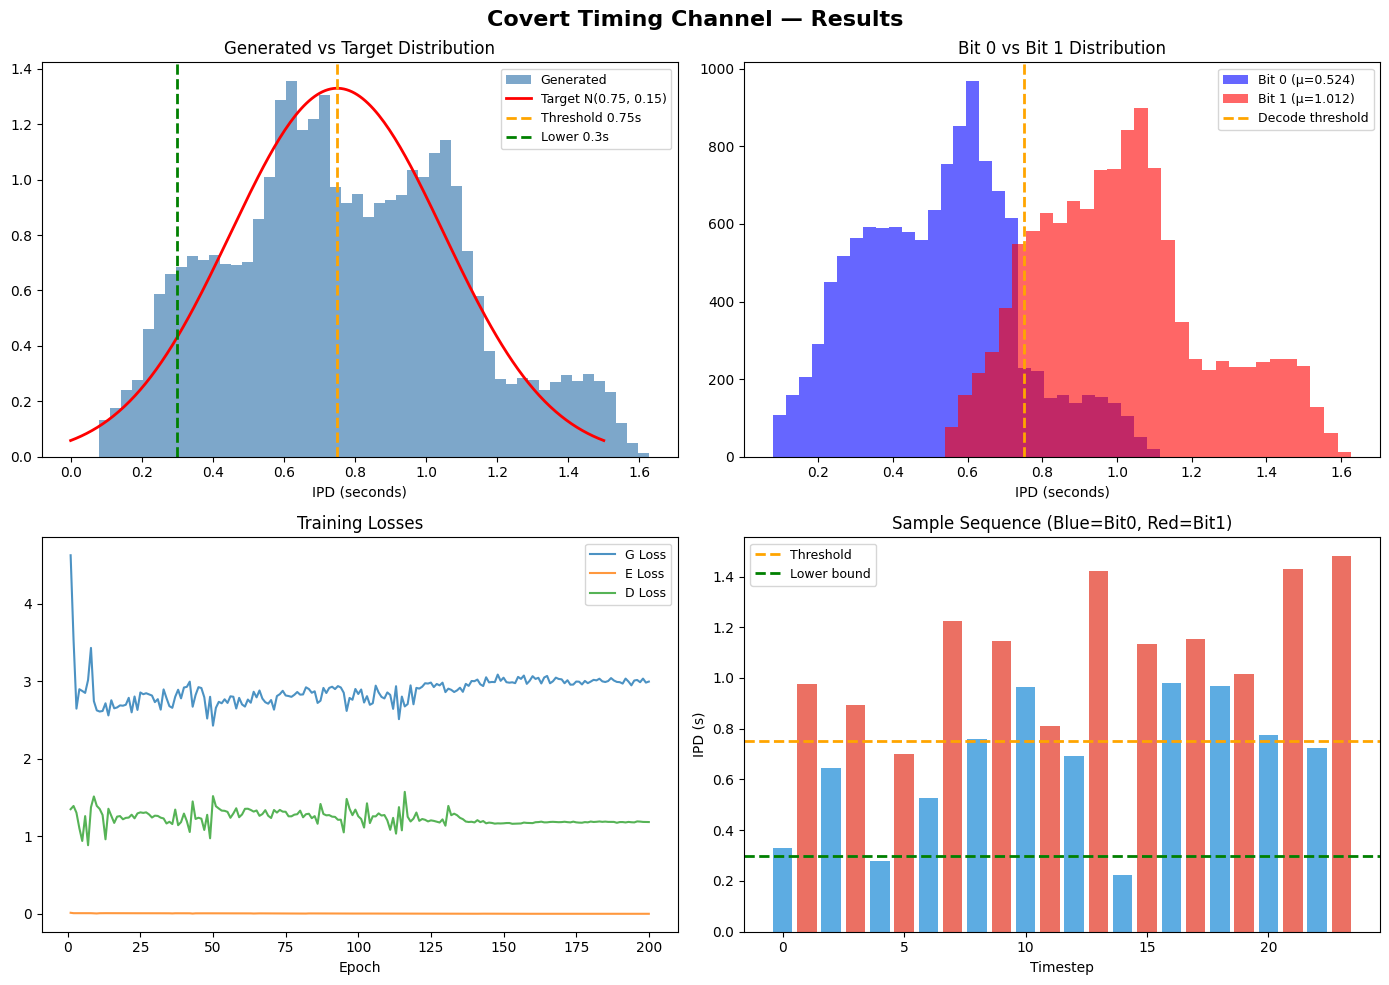

✅ Chart saved: covert_channel_results.png

🔹 PCA Visualization (Real vs Generated)...


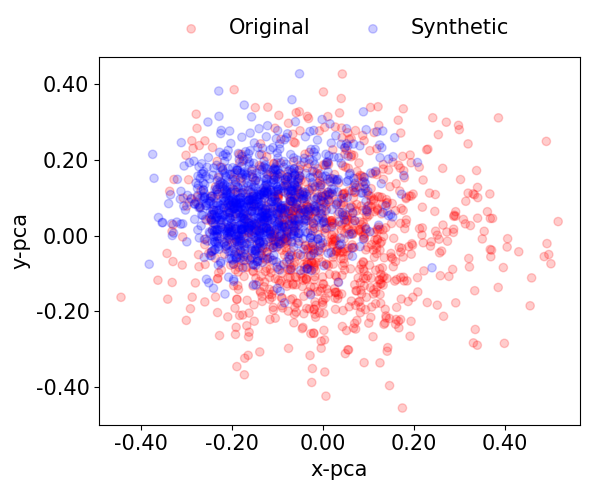


🔹 t-SNE Visualization (Real vs Generated)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0.118s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.169086


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 100 iterations with early exaggeration: 72.140518
[t-SNE] KL divergence after 300 iterations: 2.423534


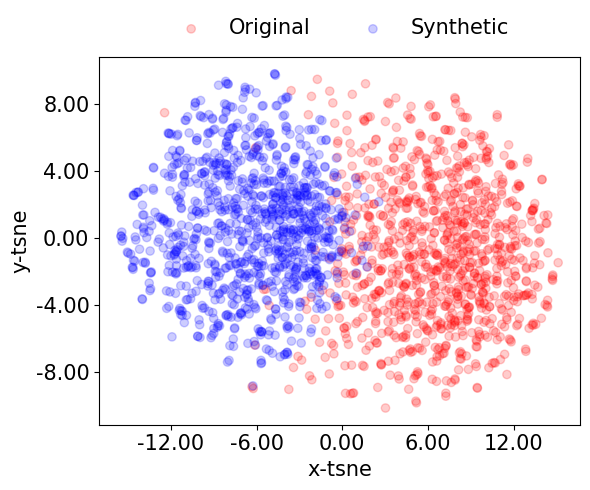

✅ Generator saved: covert_channel_generator.pth
✅ Metadata saved: covert_channel_metadata.json
✅ Full model saved: covert_channel_full_model.pth

Pipeline completed!


In [8]:
import matplotlib.pyplot as plt

# ── 8a. Biểu đồ chính (4 plots) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Covert Timing Channel — Results", fontsize=16, fontweight='bold')

# Plot 1: Generated vs Target Distribution
ax = axes[0, 0]
ax.hist(all_ipds, bins=50, density=True, alpha=0.7, color='steelblue', label='Generated')
x_range = np.linspace(0, 1.5, 200)
ax.plot(x_range, scipy.stats.norm.pdf(x_range, 0.75, 0.3), 'r-', lw=2, label='Target N(0.75, 0.15)')
ax.axvline(THRESHOLD_PHYS, color='orange', linestyle='--', lw=2, label=f'Threshold {THRESHOLD_PHYS}s')
ax.axvline(LOWER_BOUND_PHYS, color='green', linestyle='--', lw=2, label=f'Lower {LOWER_BOUND_PHYS}s')
ax.set_title('Generated vs Target Distribution')
ax.set_xlabel('IPD (seconds)')
ax.legend(fontsize=9)

# Plot 2: Bit 0 vs Bit 1
ax = axes[0, 1]
ax.hist(bit0_ipds, bins=30, alpha=0.6, label=f'Bit 0 (μ={bit0_ipds.mean():.3f})', color='blue')
ax.hist(bit1_ipds, bins=30, alpha=0.6, label=f'Bit 1 (μ={bit1_ipds.mean():.3f})', color='red')
ax.axvline(THRESHOLD_PHYS, color='orange', linestyle='--', lw=2, label='Decode threshold')
ax.set_title('Bit 0 vs Bit 1 Distribution')
ax.set_xlabel('IPD (seconds)')
ax.legend(fontsize=9)

# Plot 3: Training Losses
ax = axes[1, 0]
losses_arr = np.array(training_losses)
ax.plot(losses_arr[:, 0], losses_arr[:, 1], label='G Loss', alpha=0.8)
ax.plot(losses_arr[:, 0], losses_arr[:, 2], label='E Loss', alpha=0.8)
ax.plot(losses_arr[:, 0], losses_arr[:, 3], label='D Loss', alpha=0.8)
ax.set_title('Training Losses')
ax.set_xlabel('Epoch')
ax.legend(fontsize=9)

# Plot 4: Sample Sequence
ax = axes[1, 1]
sample_idx = 0
sample_ipd = final_val_phys[sample_idx, :, 0]
sample_bits = bits_val[sample_idx, :, 0]
colors = ['#3498db' if b == 0 else '#e74c3c' for b in sample_bits]
ax.bar(range(len(sample_ipd)), sample_ipd, color=colors, alpha=0.8)
ax.axhline(THRESHOLD_PHYS, color='orange', linestyle='--', lw=2, label='Threshold')
ax.axhline(LOWER_BOUND_PHYS, color='green', linestyle='--', lw=2, label='Lower bound')
ax.set_title('Sample Sequence (Blue=Bit0, Red=Bit1)')
ax.set_xlabel('Timestep')
ax.set_ylabel('IPD (s)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('covert_channel_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: covert_channel_results.png")

# ── 8b. PCA Plot (từ helper/metrics.py) ──
# So sánh phân phối 2D giữa cover traffic (real) và generated traffic (fake)
# Nếu 2 đám mây chồng lên nhau = Generator tạo ra traffic giống thật
print("\n🔹 PCA Visualization (Real vs Generated)...")
visualization(cover_sample, final_val_scaled_np, "pca")

# ── 8c. t-SNE Plot (từ helper/metrics.py) ──
# t-SNE nhạy hơn PCA — phát hiện cluster ẩn tốt hơn
# Nếu real (đỏ) và fake (xanh) trộn lẫn = stealth tốt
print("\n🔹 t-SNE Visualization (Real vs Generated)...")
visualization(cover_sample, final_val_scaled_np, "tsne")

# ── 8d. Save model + metadata ──
import json

model_metadata = {
    'phys_min': PHYS_MIN, 'phys_max': PHYS_MAX,
    'bit0_time': BIT0_TIME, 'bit1_time': BIT1_TIME,
    'threshold': THRESHOLD_PHYS, 'lower_bound': LOWER_BOUND_PHYS,
    'noise_scale': NOISE_SCALE, 'alpha': ALPHA,
    'hidden_dim': HIDDEN_DIM, 'num_layers': NUM_LAYERS,
    'seq_len': SEQ_LEN, 'epochs': EPOCHS,
    'batch_size': BATCH_SIZE, 'learning_rate': LEARNING_RATE,
    'module_name': MODULE_NAME,
    'validation': {
        'reliability': float(reliability),
        'decoding_errors': int(decoding_errors),      # ĐÃ SỬA DÒNG NÀY
        'violations_lower': int(violations_lower),
        'ks_stat': float(ks_stat),
        'p_value': float(p_value),
        'discriminative_score': float(d_score),
        'predictive_score': float(p_score),
        'bit0_mean': float(bit0_ipds.mean()),
        'bit1_mean': float(bit1_ipds.mean()),
    }
}

# Lưu weights
torch.save(generator.state_dict(), 'covert_channel_generator.pth')

# Lưu metadata
with open('covert_channel_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, ensure_ascii=False, indent=4)
print("✅ Generator saved: covert_channel_generator.pth")
print("✅ Metadata saved: covert_channel_metadata.json")

# Lưu toàn bộ pipeline (tất cả networks)
torch.save({
    'generator': generator.state_dict(),
    'embedder': embedder.state_dict(),
    'recovery': recovery.state_dict(),
    'supervisor': supervisor.state_dict(),
    'discriminator': discriminator_net.state_dict(),
    'config': model_metadata
}, 'covert_channel_full_model.pth')

print("✅ Full model saved: covert_channel_full_model.pth")
print("\n" + "=" * 60)
print("Pipeline completed!")
print("=" * 60)
